In [1]:
import h5py
from pathlib import Path

ARIAS = Path("/oscar/data/jlee123/procdata/adp/22-retina-arias-y1")

# List subject files (adjust glob if the layout differs)
files = sorted(ARIAS.rglob("*.h5"))
print(f"{len(files)} .h5 files found")
for f in files[:5]:
    print(" ", f.relative_to(ARIAS))

# Walk the tree of the first file
def show(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name:40s} {str(obj.shape):20s} {obj.dtype}")
    else:
        print(f"{name}/")

with h5py.File(files[0], "r") as h:
    h.visititems(show)

75 .h5 files found
  A-segment/101-1003-y1/473-p1a.h5
  A-segment/101-1003-y1/474-p1a.h5
  A-segment/101-1004-y1/481-p1a.h5
  A-segment/101-1004-y1/482-p1a.h5
  A-segment/101-1006-y1/501-p1a.h5
oct                                      (512, 512, 496)      float32
octa                                     (512, 512, 496)      float32
p1/
p1/did                                   ()                   object
p1/eid                                   ()                   object
p1/hdr/
p1/hdr/BScanHdrSize                      (1, 1)               float64
p1/hdr/DOB                               (1, 1)               float64
p1/hdr/Distance                          (1, 1)               float64
p1/hdr/ExamTime                          (1, 1)               float64
p1/hdr/FieldSizeSlo                      (1, 1)               float64
p1/hdr/GridOffset                        (1, 1)               float64
p1/hdr/GridType                          (1, 1)               float64
p1/hdr/ID                 

In [2]:
import numpy as np

SUBJ = files[0]

with h5py.File(SUBJ, "r") as h:
    octa = h["octa"][:]        # VERIFY key name against Cell 1 output
    lyr  = h["r1/lyr"][:]      # VERIFY key name

print("octa:", octa.shape, octa.dtype)
print("lyr :", lyr.shape, lyr.dtype)

# Which codes actually appear, and how much of the volume each occupies
codes, counts = np.unique(lyr, return_counts=True)
for c, n in zip(codes, counts):
    print(f"code {c:2d}: {n:>12,} voxels ({100*n/lyr.size:5.2f}%)")

octa: (512, 512, 496) float32
lyr : (512, 512, 496) uint8
code  0:   92,848,847 voxels (71.41%)
code  1:    5,242,880 voxels ( 4.03%)
code  2:    3,261,335 voxels ( 2.51%)
code  3:    2,684,995 voxels ( 2.07%)
code  4:    1,085,370 voxels ( 0.83%)
code  5:    1,150,206 voxels ( 0.88%)
code  6:    1,466,048 voxels ( 1.13%)
code  7:      832,681 voxels ( 0.64%)
code  8:    2,162,174 voxels ( 1.66%)
code  9:    3,472,866 voxels ( 2.67%)
code 10:    1,572,806 voxels ( 1.21%)
code 11:    1,309,340 voxels ( 1.01%)
code 12:    1,581,951 voxels ( 1.22%)
code 13:      866,156 voxels ( 0.67%)
code 14:   10,485,769 voxels ( 8.06%)


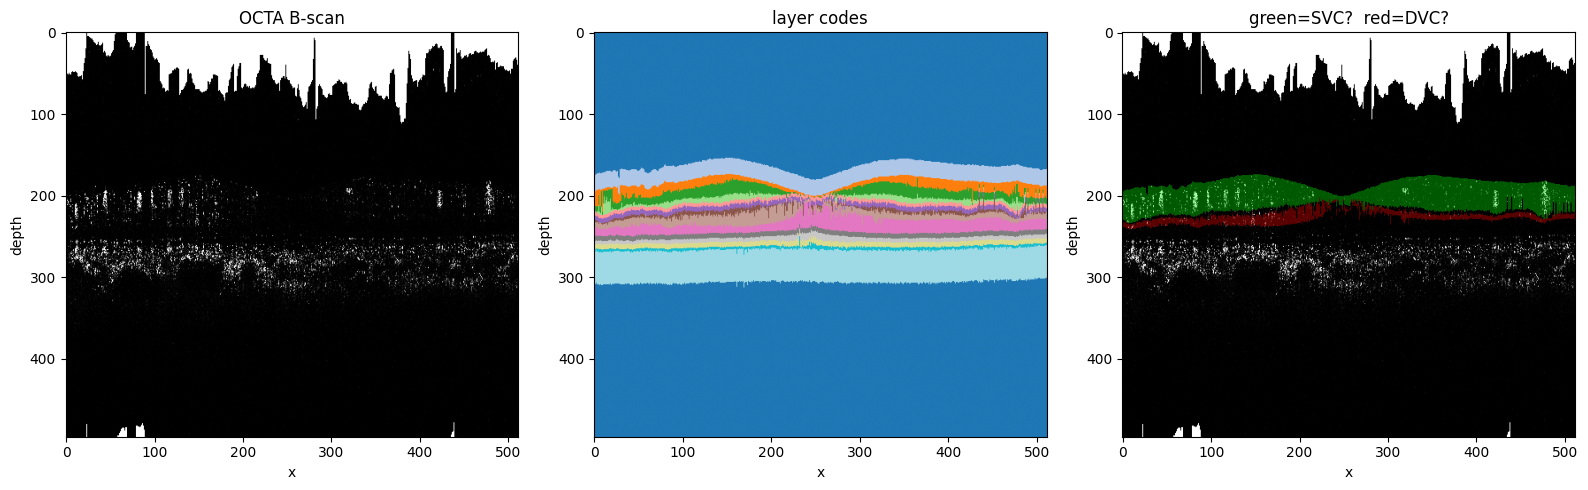

In [3]:
import matplotlib.pyplot as plt

Y = octa.shape[1] // 2         # middle cross-section
SVC_CODES = (2, 3, 4, 5, 6)    # UNCONFIRMED
DVC_CODES = (8,)               # UNCONFIRMED

bscan = octa[:, Y, :].T        # (depth, x)
lscan = lyr[:, Y, :].T

svc_mask = np.isin(lscan, SVC_CODES)
dvc_mask = np.isin(lscan, DVC_CODES)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(bscan, cmap="gray", aspect="auto"); ax[0].set_title("OCTA B-scan")
ax[1].imshow(lscan, cmap="tab20", aspect="auto"); ax[1].set_title("layer codes")

ax[2].imshow(bscan, cmap="gray", aspect="auto")
ov = np.zeros((*bscan.shape, 4))
ov[svc_mask] = [0, 1, 0, 0.35]     # green = presumed SVC
ov[dvc_mask] = [1, 0, 0, 0.35]     # red   = presumed DVC
ax[2].imshow(ov, aspect="auto"); ax[2].set_title("green=SVC?  red=DVC?")
for a in ax: a.set_xlabel("x"); a.set_ylabel("depth")
plt.tight_layout(); plt.show()

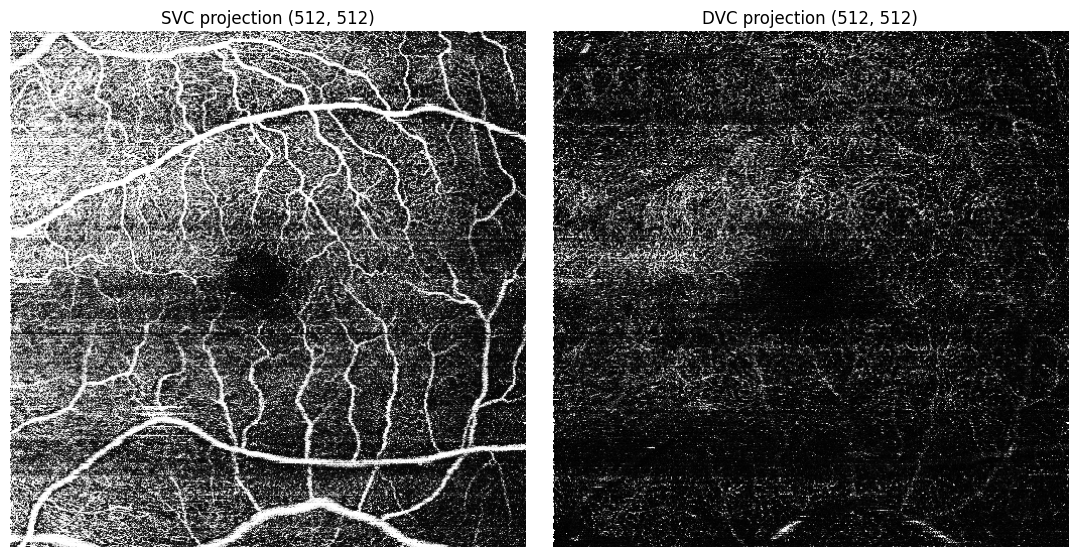

In [4]:
def enface(vol, lyrvol, codes):
    """Max projection through a layer slab. Depth assumed to be axis 2."""
    m = np.isin(lyrvol, codes)
    return np.where(m, vol, -np.inf).max(axis=2)

svc = enface(octa, lyr, SVC_CODES)
dvc = enface(octa, lyr, DVC_CODES)
svc = np.where(np.isfinite(svc), svc, 0)
dvc = np.where(np.isfinite(dvc), dvc, 0)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(svc, cmap="gray"); ax[0].set_title(f"SVC projection {svc.shape}")
ax[1].imshow(dvc, cmap="gray"); ax[1].set_title(f"DVC projection {dvc.shape}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

In [5]:
import numpy as np

with h5py.File(SUBJ, "r") as h:
    scanpos = h["p1/hdr/ScanPosition"][:].flatten()
    print("eye:", "".join(chr(c) for c in scanpos))
    for k in ["ScaleX", "ScaleZ", "SizeX", "SizeZ", "NumBScans"]:
        print(f"{k}: {h[f'p1/hdr/{k}'][()].item():.6f}")
    print("DOB (raw):", h["p1/hdr/DOB"][()].item())
    print("VisitDate (raw):", h["p1/hdr/VisitDate"][()].item())
    q = h["p1/hdrBscanAng/Quality"][:].flatten()
    print(f"OCTA quality: mean {q.mean():.1f}, min {q.min():.1f}, max {q.max():.1f}")
    print("snrAng:", h["p1/opt/snrAng"][()].item())
    for k in ["lyrD", "lyrI", "lyrZ"]:
        print(f"{k}:", np.round(h[f"r1/{k}"][:].flatten(), 3))

eye: OS  
ScaleX: 0.011551
ScaleZ: 0.003872
SizeX: 512.000000
SizeZ: 496.000000
NumBScans: 512.000000
DOB (raw): 19541.0
VisitDate (raw): 44908.80510416667
OCTA quality: mean 30.3, min 24.0, max 40.2
snrAng: 0.0
lyrD: [0.002 0.046 0.061 0.07  0.058 0.038 0.023 0.033 0.008 0.014 0.052 0.077
 0.141 0.12 ]
lyrI: [0.001 0.152 0.047 0.036 0.032 0.015 0.011 0.019 0.005 0.016 0.096 0.169
 0.333 0.028]
lyrZ: [167.599 193.317 195.266 203.142 206.611 211.693 218.732 225.172 229.778
 242.073 247.478 253.107 257.537 279.409]


In [6]:
for codes in [(8,), (7,8), (8,9), (7,8,9)]:
    d = enface(octa, lyr, codes)
    d = np.where(np.isfinite(d), d, 0)
    print(f"codes {codes}: mean {d.mean():.4f}, nonzero {100*(d>0).mean():.1f}%")

codes (8,): mean 0.1186, nonzero 99.8%
codes (7, 8): mean 0.1328, nonzero 99.9%
codes (8, 9): mean 0.1277, nonzero 100.0%
codes (7, 8, 9): mean 0.1405, nonzero 100.0%


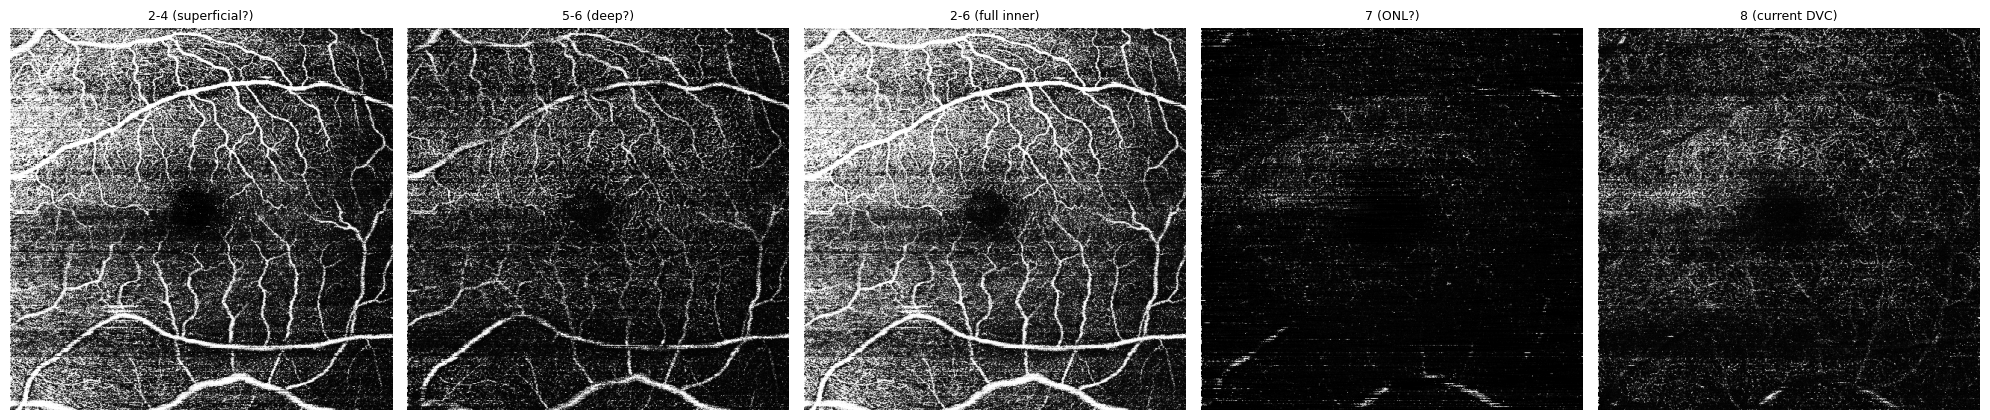

In [7]:
tests = [("2-4 (superficial?)", (2,3,4)),
         ("5-6 (deep?)",        (5,6)),
         ("2-6 (full inner)",   (2,3,4,5,6)),
         ("7 (ONL?)",           (7,)),
         ("8 (current DVC)",    (8,))]

fig, ax = plt.subplots(1, len(tests), figsize=(4*len(tests), 4.2))
for a, (name, codes) in zip(ax, tests):
    p = enface(octa, lyr, codes)
    p = np.where(np.isfinite(p), p, 0)
    a.imshow(p, cmap="gray"); a.set_title(name, fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

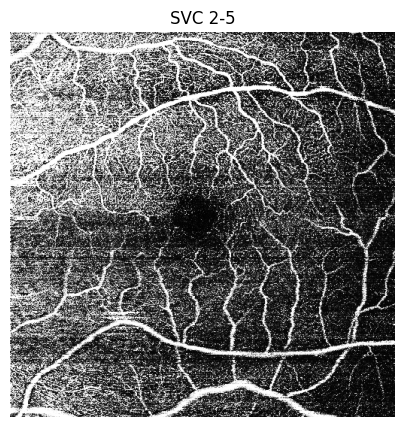

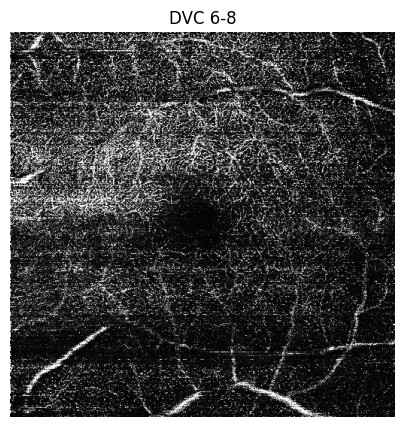

In [9]:
for name, codes in [("SVC 2-5", (2,3,4,5)), ("DVC 6-8", (6,7,8))]:
    p = enface(octa, lyr, codes); p = np.where(np.isfinite(p), p, 0)
    plt.figure(figsize=(5,5)); plt.imshow(p, cmap="gray"); plt.title(name); plt.axis("off"); plt.show()

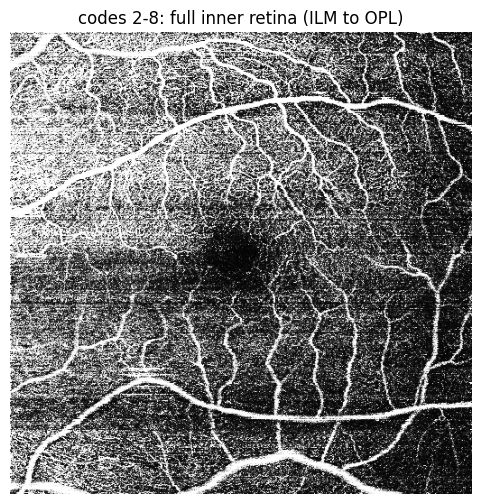

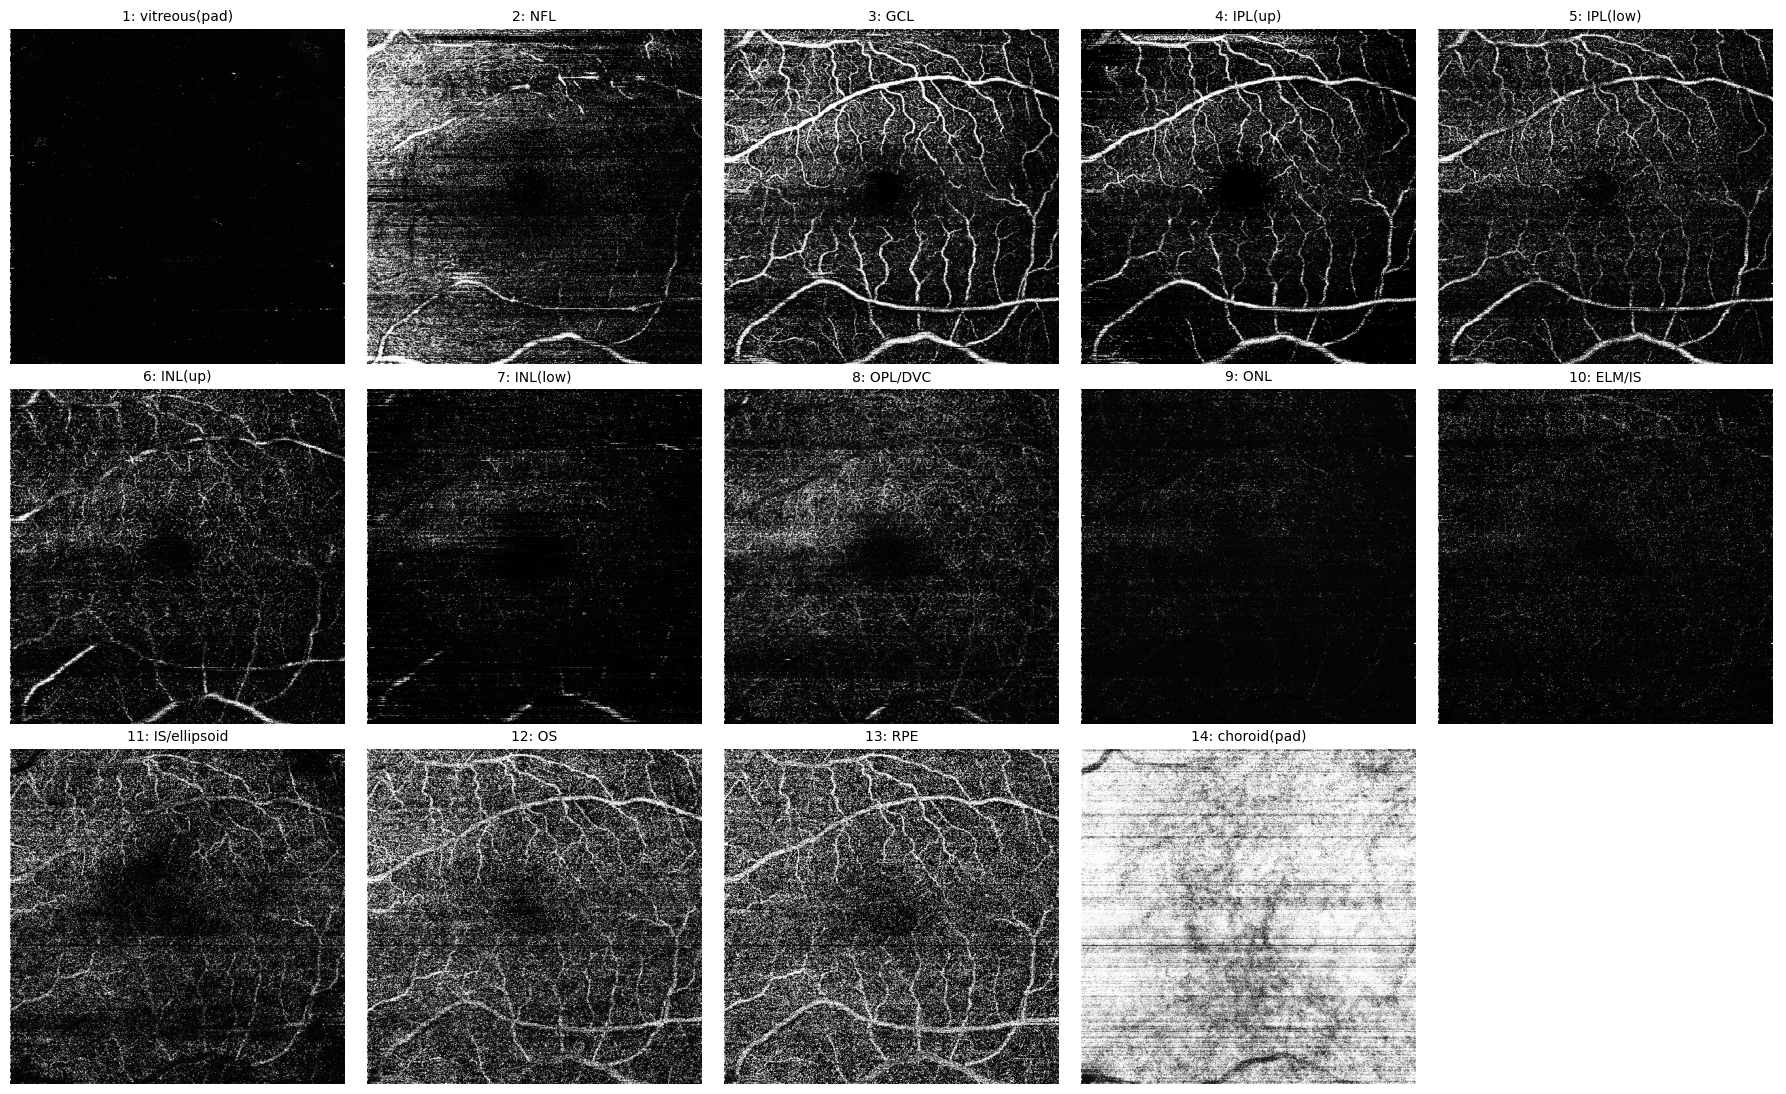

In [10]:
LAYERS = {1:"vitreous(pad)", 2:"NFL", 3:"GCL", 4:"IPL(up)", 5:"IPL(low)",
          6:"INL(up)", 7:"INL(low)", 8:"OPL/DVC", 9:"ONL", 10:"ELM/IS",
          11:"IS/ellipsoid", 12:"OS", 13:"RPE", 14:"choroid(pad)"}

def proj(codes):
    p = enface(octa, lyr, codes)
    return np.where(np.isfinite(p), p, 0)

# --- full retinal vascular slab (ILM to OPL), matches OCTA-500 B5 ---
full = proj((2,3,4,5,6,7,8))
plt.figure(figsize=(6,6))
plt.imshow(full, cmap="gray"); plt.title("codes 2-8: full inner retina (ILM to OPL)")
plt.axis("off"); plt.show()

# --- all 14 individually ---
SHARED_SCALE = True          # True = honest brightness comparison
                             # False = per-panel stretch, reveals faint structure
vmax = np.percentile(full, 99.5)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
for ax, code in zip(axes.flat, range(1, 15)):
    p = proj((code,))
    if SHARED_SCALE:
        ax.imshow(p, cmap="gray", vmin=0, vmax=vmax)
    else:
        ax.imshow(p, cmap="gray", vmin=0, vmax=max(np.percentile(p, 99.5), 1e-6))
    ax.set_title(f"{code}: {LAYERS[code]}", fontsize=10)
    ax.axis("off")
axes.flat[14].axis("off")
plt.tight_layout(); plt.show()